<a href="https://colab.research.google.com/github/meghanlenskold/gbb885-final-assignment-lenskold-m/blob/main/GB885_Final_Assignment_Lenskold_M.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RUSH Sales Analysis
EDA and Business Questions Prepared for VP of US Sales

**Questions to answer:**


1. What product category (product) had the highest sales (in dollars) in 2021? How much did it sell?
2. What state had the highest sales (in dollars) of women's products in 2021, and how much was it?
3. What state had the highest sales (in dollars) of men's products in 2021, and how much was it?
4. What retailer purchased the most units in 2021? In 2020?



Load the Data

In [1]:
# Import libraries.
import pandas as pd
import numpy as np

In [2]:
# Import data.
from google.colab import files
uploaded = files.upload()

sales = pd.read_csv('TABLE_SALES_885.csv')
retailer = pd.read_csv('TABLE_RETAILER_885.csv')
products = pd.read_csv('TABLE_PRODUCTS_885.csv', sep='|')

Saving TABLE_SALES_885.csv to TABLE_SALES_885 (1).csv
Saving TABLE_RETAILER_885.csv to TABLE_RETAILER_885 (1).csv
Saving TABLE_PRODUCTS_885.csv to TABLE_PRODUCTS_885 (1).csv


In [3]:
# Change pandas settings.
pd.set_option('display.max_columns', None)

In [4]:
# Preview each table.
sales.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
0,1,A00MOHCO,1/1/2020,1,1,2020,20,50.0,1200,0.5,In-store
1,7,A00MOHCO,1/7/2020,1,7,2020,20,50.0,1250,0.5,In-store
2,13,A00MOHCO,1/25/2020,1,25,2020,20,50.0,1220,0.5,Outlet
3,19,A00MOHCO,1/31/2020,1,31,2020,20,50.0,1200,0.5,Outlet
4,25,A00MOHCO,2/6/2020,2,6,2020,20,60.0,1220,0.5,Outlet


In [5]:
retailer.head()

,RETAILER_ID,RETAILER,REGION,STATE,CITY
0,A00MOHCO,Amazon,Midwest,Ohio,Columbus
1,A00NMAPO,Amazon,Northeast,Maine,Portland
2,A00NMABO,Amazon,Northeast,Massachusetts,Boston
3,A00NNEMA,Amazon,Northeast,New Hampshire,Manchester
4,A00NVEBU,Amazon,Northeast,Vermont,Burlington


In [6]:
products.head()

,PRODUCT_ID,PRODUCT_NAME
0,20,Men's Street Footwear
1,30,Men's Athletic Footwear
2,120,Women's Street Footwear
3,130,Women's Athletic Footwear
4,40,Men's Apparel


Inspect the Data

In [7]:
# Check shape.
sales.shape

(9648, 11)

In [8]:
retailer.shape

(110, 5)

In [9]:
products.shape

(6, 2)

In [10]:
#Check datatypes / nulls.
sales.info()

# Units sold needs to be changed to a numeric.
# Prices per unit and units sold are missing in two rows.
# Invoice date should change to datetime.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9648 entries, 0 to 9647
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ORDER_ID          9648 non-null   int64  
 1   RETAILER_ID       9648 non-null   object 
 2   INVOICE_DATE      9648 non-null   object 
 3   MONTH             9648 non-null   int64  
 4   DAY               9648 non-null   int64  
 5   YEAR              9648 non-null   int64  
 6   PRODUCT_ID        9648 non-null   int64  
 7   PRICE_PER_UNIT    9646 non-null   float64
 8   UNITS_SOLD        9648 non-null   object 
 9   OPERATING_MARGIN  9648 non-null   float64
 10  SALES_METHOD      9648 non-null   object 
dtypes: float64(2), int64(5), object(4)
memory usage: 829.3+ KB


In [11]:
retailer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   RETAILER_ID  110 non-null    object
 1   RETAILER     110 non-null    object
 2   REGION       110 non-null    object
 3   STATE        110 non-null    object
 4   CITY         110 non-null    object
dtypes: object(5)
memory usage: 4.4+ KB


In [12]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   PRODUCT_ID    6 non-null      int64 
 1   PRODUCT_NAME  6 non-null      object
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


In [13]:
# Count duplicates.
print(sales.duplicated().sum())
print(retailer.duplicated().sum())
print(products.duplicated().sum())

0
0
0


Clean the data.

In [14]:
# Changed UNITS_SOLD to numeric.
sales['UNITS_SOLD'] = pd.to_numeric(sales['UNITS_SOLD'], errors='coerce')

In [15]:
# Convert invoice date.
sales['INVOICE_DATE'] = pd.to_datetime(sales['INVOICE_DATE'])

In [16]:
# Check the rows for the missing price.
sales[sales['PRICE_PER_UNIT'].isna()]

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD
98,591,A00NVEBU,2020-04-02,4,2,2020,20,NaN,525.0,0.35,In-store
99,597,A00NVEBU,2020-04-08,4,8,2020,20,NaN,525.0,0.50,In-store


In [17]:
# Drop.
sales = sales.dropna(subset=['UNITS_SOLD','PRICE_PER_UNIT'])
sales.isna().sum()

,0
ORDER_ID,0
RETAILER_ID,0
INVOICE_DATE,0
MONTH,0
DAY,0
YEAR,0
PRODUCT_ID,0
PRICE_PER_UNIT,0
UNITS_SOLD,0
OPERATING_MARGIN,0


Create Total Sales Column (for revenue)

In [18]:
# Calculate total sales for each order.
sales['TOTAL_SALES'] =sales['PRICE_PER_UNIT'] * sales['UNITS_SOLD']
sales.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,TOTAL_SALES
0,1,A00MOHCO,2020-01-01,1,1,2020,20,50.0,1200.0,0.5,In-store,60000.0
1,7,A00MOHCO,2020-01-07,1,7,2020,20,50.0,1250.0,0.5,In-store,62500.0
2,13,A00MOHCO,2020-01-25,1,25,2020,20,50.0,1220.0,0.5,Outlet,61000.0
3,19,A00MOHCO,2020-01-31,1,31,2020,20,50.0,1200.0,0.5,Outlet,60000.0
4,25,A00MOHCO,2020-02-06,2,6,2020,20,60.0,1220.0,0.5,Outlet,73200.0


In [19]:
# Check for outliers in the total sales.
pd.set_option('display.float_format', '{:.2f}'.format)
sales['TOTAL_SALES'].describe()

,TOTAL_SALES
count,9644.00
mean,17841.43
std,529531.30
min,0.00
25%,4060.00
50%,7803.50
75%,15841.00
max,51999480.00


In [20]:
# Find the order(s) driving the extreme high max.
sales.sort_values('TOTAL_SALES', ascending=False).head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,TOTAL_SALES
423,2536,F00NNEMA,2021-05-23,5,23,2021,20,99999.00,520.00,0.40,Online,51999480.00
8368,1971,F00MMIST,2021-06-17,6,17,2021,140,110.00,750.00,0.35,Online,82500.00
8272,1395,F00WHAHO,2021-06-17,6,17,2021,140,110.00,750.00,0.45,In-store,82500.00
233,1396,F00WHAHO,2021-07-16,7,16,2021,20,90.00,900.00,0.30,In-store,81000.00
329,1972,F00MMIST,2021-07-16,7,16,2021,20,90.00,900.00,0.40,Online,81000.00


In [21]:
# Drop the outlier.
sales = sales[sales['ORDER_ID'] != 2536]

In [22]:
# Confirm by checking stats again.
sales['TOTAL_SALES'].describe()

,TOTAL_SALES
count,9643.00
mean,12450.82
std,12715.75
min,0.00
25%,4060.00
50%,7802.00
75%,15813.00
max,82500.00


Merge the Tables

In [23]:
# Merge sales data with retailer data.
sales_retailer = pd.merge(sales, retailer, on='RETAILER_ID', how='left')
sales_retailer.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,TOTAL_SALES,RETAILER,REGION,STATE,CITY
0,1,A00MOHCO,2020-01-01,1,1,2020,20,50.00,1200.00,0.50,In-store,60000.00,Amazon,Midwest,Ohio,Columbus
1,7,A00MOHCO,2020-01-07,1,7,2020,20,50.00,1250.00,0.50,In-store,62500.00,Amazon,Midwest,Ohio,Columbus
2,13,A00MOHCO,2020-01-25,1,25,2020,20,50.00,1220.00,0.50,Outlet,61000.00,Amazon,Midwest,Ohio,Columbus
3,19,A00MOHCO,2020-01-31,1,31,2020,20,50.00,1200.00,0.50,Outlet,60000.00,Amazon,Midwest,Ohio,Columbus
4,25,A00MOHCO,2020-02-06,2,6,2020,20,60.00,1220.00,0.50,Outlet,73200.00,Amazon,Midwest,Ohio,Columbus


In [24]:
# Merge product data to sales_retailer.
merged_df = pd.merge(sales_retailer, products, on='PRODUCT_ID', how='left')
merged_df.head()

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,TOTAL_SALES,RETAILER,REGION,STATE,CITY,PRODUCT_NAME
0,1,A00MOHCO,2020-01-01,1,1,2020,20,50.00,1200.00,0.50,In-store,60000.00,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
1,7,A00MOHCO,2020-01-07,1,7,2020,20,50.00,1250.00,0.50,In-store,62500.00,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
2,13,A00MOHCO,2020-01-25,1,25,2020,20,50.00,1220.00,0.50,Outlet,61000.00,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
3,19,A00MOHCO,2020-01-31,1,31,2020,20,50.00,1200.00,0.50,Outlet,60000.00,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear
4,25,A00MOHCO,2020-02-06,2,6,2020,20,60.00,1220.00,0.50,Outlet,73200.00,Amazon,Midwest,Ohio,Columbus,Men's Street Footwear


In [25]:
# Confirm no nulls.
merged_df.isna().sum()

,0
ORDER_ID,0
RETAILER_ID,0
INVOICE_DATE,0
MONTH,0
DAY,0
YEAR,0
PRODUCT_ID,0
PRICE_PER_UNIT,0
UNITS_SOLD,0
OPERATING_MARGIN,0


In [26]:
# Check for null details.
merged_df[merged_df['RETAILER'].isna()]

,ORDER_ID,RETAILER_ID,INVOICE_DATE,MONTH,DAY,YEAR,PRODUCT_ID,PRICE_PER_UNIT,UNITS_SOLD,OPERATING_MARGIN,SALES_METHOD,TOTAL_SALES,RETAILER,REGION,STATE,CITY,PRODUCT_NAME
1529,8668,999999999,2021-07-23,7,23,2021,20,60.00,298.00,0.42,Outlet,17880.00,NaN,NaN,NaN,NaN,Men's Street Footwear


In [27]:
# Drop null.
merged_df = merged_df.dropna(subset=['RETAILER'])
merged_df.isna().sum()

,0
ORDER_ID,0
RETAILER_ID,0
INVOICE_DATE,0
MONTH,0
DAY,0
YEAR,0
PRODUCT_ID,0
PRICE_PER_UNIT,0
UNITS_SOLD,0
OPERATING_MARGIN,0


## **Business Questions**

**Question 1:** What product category had the highest sales (in dollars) in 2021? How much did it sell?

In [28]:
prodcategory = merged_df[merged_df['YEAR']==2021].groupby('PRODUCT_NAME')['TOTAL_SALES'].sum().sort_values(ascending=False)
prodcategory

,TOTAL_SALES
PRODUCT_NAME,
Men's Street Footwear,23257356.00
Women's Apparel,19658904.00
Men's Athletic Footwear,16702706.00
Women's Street Footwear,13807909.00
Men's Apparel,13325861.00
Women's Athletic Footwear,11381041.00


*Answer: Men's Street Footwear had  the highest sales with $23,257,356 in 2021.*

**Question 2:** What state had the highest sales (in dollars) of women's products in 2021? How much was it?

In [29]:
women_2021 = merged_df[(merged_df['YEAR']==2021) & (merged_df['PRODUCT_NAME'].str.contains('Women'))]
women_sales_2021 = women_2021.groupby('STATE')['TOTAL_SALES'].sum().sort_values(ascending=False)
women_sales_2021

,TOTAL_SALES
STATE,
Maine,2176301.00
Delaware,2023575.00
New Hampshire,1916400.00
Arizona,1798900.00
Missouri,1771992.00
Illinois,1743277.00
New York,1736862.00
Virginia,1719886.00
Nebraska,1712680.00


*Answer: Maine had the highest sales in 2021 for women's products. RUSH sold $2,176,301 worth of women's products in Maine in 2021.*

**Question 3:** What state had the highest sales (in dollars) of men's products in 2021? How much was it?

In [30]:
men_2021 = merged_df[(merged_df['YEAR']==2021) & (merged_df['PRODUCT_NAME'].str.contains('Men'))]
men_sales_2021 = men_2021.groupby('STATE')['TOTAL_SALES'].sum().sort_values(ascending=False)
men_sales_2021

,TOTAL_SALES
STATE,
Delaware,2334300.00
Arizona,2261025.00
Maine,2217190.00
New Hampshire,2208600.00
New York,2114999.00
Illinois,2093438.00
Missouri,1951530.00
Connecticut,1926568.00
Nebraska,1718726.00


*Answer: The highest sales for men's products were in the state of Delaware. RUSH sold $2,334,300 there in 2021.*

**Question 4:** What retailer purchased the most units in 2021? In 2020?

In [31]:
# 2021
units_2021 = merged_df[merged_df['YEAR']==2021].groupby('RETAILER')['UNITS_SOLD'].sum().sort_values(ascending=False)
units_2021

,UNITS_SOLD
RETAILER,
Foot Locker,1096890.00
West Gear,315502.00
Sports Direct,256363.00
Amazon,205570.00
Kohl's,136950.00
Walmart,58286.00


In [32]:
# 2020
units_2020 = merged_df[merged_df['YEAR']==2020].groupby('RETAILER')['UNITS_SOLD'].sum().sort_values(ascending=False)
units_2020

,UNITS_SOLD
RETAILER,
Amazon,316880.00
Kohl's,68686.00
West Gear,57334.00
Sports Direct,18399.00


*Answer: In 2021, Foot Locker was RUSH's top retailer, purchasing 1,096,890 units.*

*In 2020, Amazon was the top retailer, buying 316,880 units.*

## Additional Trends

In [33]:
# Monthly sales trend by year
monthly_sales = merged_df.groupby(['YEAR', 'MONTH'])['TOTAL_SALES'].sum().unstack(level=0)
monthly_sales

YEAR,2020,2021
MONTH,,
1,2312746.00,7580341.00
2,2140813.00,6256659.00
3,2474202.00,5307200.00
4,3130081.00,6595521.00
5,2164764.00,8711210.00
6,1084194.00,8890823.00
7,2182388.00,10639451.00
8,2641630.00,9897471.00
9,2367686.00,8163271.00


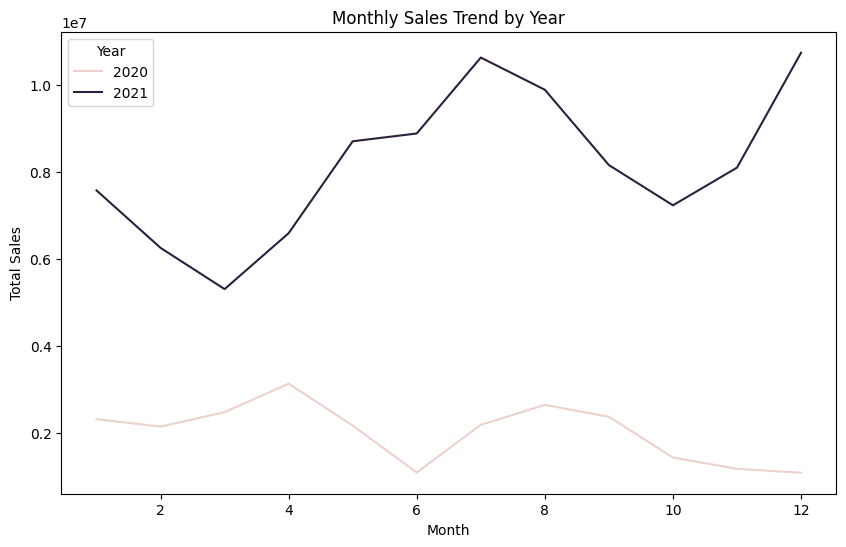

In [34]:
# Visualization for monthly sales trends by year.

# Import visualization library.
import matplotlib.pyplot as plt
import seaborn as sns

# Plot.
plt.figure(figsize=(10, 6))
sns.lineplot(data=merged_df.groupby(['YEAR', 'MONTH'])['TOTAL_SALES'].sum().reset_index(),x='MONTH',y='TOTAL_SALES',hue='YEAR')
plt.title('Monthly Sales Trend by Year')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.legend(title='Year')

In [37]:
# Regional performance by year.
merged_df.groupby(['YEAR','REGION'])['TOTAL_SALES'].sum()

YEAR  REGION   
2020  Midwest      6634299.00
      Northeast    7031424.00
      South        1281362.00
      Southeast    5358073.00
      West         3869167.00
2021  Midwest     24799271.00
      Northeast   32216000.00
      South       10169060.00
      Southeast    9998063.00
      West        20951383.00
Name: TOTAL_SALES, dtype: float64

In [39]:
# Average order size by retailer
merged_df.groupby('RETAILER')['TOTAL_SALES'].mean().sort_values(ascending=False)

,TOTAL_SALES
RETAILER,
Amazon,29527.59
Foot Locker,20341.59
Kohl's,10536.71
Sports Direct,6244.09
West Gear,5168.07
Walmart,3037.04
